completeness for province

In [2]:
from pathlib import Path
from met_pipeline.io import load_excel, load_csv, normalize_kab_kota
from met_pipeline.quality import compute_entity_completeness

PROJECT_ROOT = Path.cwd().parent

df = load_excel(
    PROJECT_ROOT / "data" / "raw" / "master_timbulan_sipsn_new.xlsx",
    header=0,
)

ref_df = load_csv(
    PROJECT_ROOT / "data" / "reference" / "master_kab_reference_final.csv"
)


In [7]:
# Rename reference columns
ref_df = ref_df.rename(columns={
    "provinsi": "Provinsi",
    "kab_kota": "Kabupaten/Kota"
})

# Rename timbulan columns
df = df.rename(columns={
    "nama_provinsi": "Provinsi",
    "nama_kabkota": "Kabupaten/Kota",
    "tahun": "Tahun"
})

In [8]:
# Remove whitespace
for col in ["Provinsi", "Kabupaten/Kota"]:
    ref_df[col] = ref_df[col].str.strip()
    df[col] = df[col].str.strip()

In [9]:
df_valid = df[df["jml_timbulan_tahun"].notna()]

In [10]:
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab_Resmi")
)

In [11]:
reported = (
    df_valid.groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Melapor")
)

In [12]:
completeness = reported.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

completeness["Completeness"] = (
    completeness["Kab_Melapor"] /
    completeness["Total_Kab_Resmi"]
)

# Optional 0–10 scale
completeness["Score_0_10"] = completeness["Completeness"] * 10

In [13]:
completeness.sort_values(["Provinsi", "Tahun"]).head(20)

,Provinsi,Tahun,Kab_Melapor,Total_Kab_Resmi,Completeness,Score_0_10
0,Aceh,2019,1,23.0,0.043478,0.434783
1,Aceh,2020,6,23.0,0.260870,2.608696
2,Aceh,2021,2,23.0,0.086957,0.869565
3,Aceh,2022,8,23.0,0.347826,3.478261
4,Aceh,2023,13,23.0,0.565217,5.652174
5,Aceh,2024,23,23.0,1.000000,10.000000
6,Aceh,2025,21,23.0,0.913043,9.130435
7,Bali,2020,5,9.0,0.555556,5.555556
8,Bali,2021,4,9.0,0.444444,4.444444
9,Bali,2022,4,9.0,0.444444,4.444444


In [14]:
missing = set(df["Kabupaten/Kota"]) - set(ref_df["Kabupaten/Kota"])
print(len(missing))
print(list(missing)[:10])

5
['Kab. Pangkajene Kepulauan', 'Kota Pematang Siantar', 'Kota Padangsidimpuan', 'Kab. Timor Tengah Selatan', 'Kab. Pangkajene dan Kepulauan']


In [15]:
# Manual correction dictionary
name_corrections = {
    "Kab. Pangkajene Kepulauan": "Kab. Pangkajene dan Kepulauan",
    "Kota Pematang Siantar": "Kota Pematangsiantar",
    "Kota Padangsidimpuan": "Kota Padang Sidempuan",
}

# Apply corrections
df["Kabupaten/Kota"] = df["Kabupaten/Kota"].replace(name_corrections)

In [16]:
missing = set(df["Kabupaten/Kota"]) - set(ref_df["Kabupaten/Kota"])
print(len(missing))
print(missing)

2
{'Kab. Timor Tengah Selatan', 'Kab. Pangkajene dan Kepulauan'}


In [17]:
# Search reference for anything containing 'Pangkajene'
ref_df[ref_df["Kabupaten/Kota"].str.contains("Pangkajene", case=False)]

,Provinsi,Kabupaten/Kota
388,Sulawesi Selatan,Kab. Pangkajene Dan Kepulauan


In [18]:
ref_df[ref_df["Kabupaten/Kota"].str.contains("Timor", case=False)]

,Provinsi,Kabupaten/Kota
294,Nusa Tenggara Timur,Kab Timor Tengah Selatan
314,Nusa Tenggara Timur,Kab. Timor Tengah Utara


In [19]:
def clean_kab_name(x):
    x = x.strip()
    x = x.replace("Kabupaten", "Kab")
    x = x.replace("Kab.", "Kab")
    x = x.replace("Kota ", "Kota ")
    x = x.replace("Dan", "dan")
    x = x.replace("  ", " ")
    return x

ref_df["Kabupaten/Kota"] = ref_df["Kabupaten/Kota"].apply(clean_kab_name)
df["Kabupaten/Kota"] = df["Kabupaten/Kota"].apply(clean_kab_name)

In [20]:
missing = set(df["Kabupaten/Kota"]) - set(ref_df["Kabupaten/Kota"])
print(len(missing))
print(missing)

0
set()


In [21]:
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab_Resmi")
)

In [22]:
df_valid = df[df["jml_timbulan_tahun"].notna()]

In [23]:
reported = (
    df_valid.groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Melapor")
)

In [24]:
completeness = reported.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

In [25]:
completeness["Completeness"] = (
    completeness["Kab_Melapor"] /
    completeness["Total_Kab_Resmi"]
)

completeness["Score_0_10"] = completeness["Completeness"] * 10

In [26]:
completeness = completeness.sort_values(["Provinsi", "Tahun"])
completeness.head(20)

,Provinsi,Tahun,Kab_Melapor,Total_Kab_Resmi,Completeness,Score_0_10
0,Aceh,2019,1,23.0,0.043478,0.434783
1,Aceh,2020,6,23.0,0.260870,2.608696
2,Aceh,2021,2,23.0,0.086957,0.869565
3,Aceh,2022,8,23.0,0.347826,3.478261
4,Aceh,2023,13,23.0,0.565217,5.652174
5,Aceh,2024,23,23.0,1.000000,10.000000
6,Aceh,2025,21,23.0,0.913043,9.130435
7,Bali,2020,5,9.0,0.555556,5.555556
8,Bali,2021,4,9.0,0.444444,4.444444
9,Bali,2022,4,9.0,0.444444,4.444444


In [27]:
prov_summary = (
    completeness.groupby("Provinsi")["Completeness"]
    .mean()
    .reset_index(name="Avg_Completeness_2019_2025")
)

prov_summary.sort_values("Avg_Completeness_2019_2025").head()

,Provinsi,Avg_Completeness_2019_2025
27,Papua Pegunungan,0.125000
38,Sumatera Utara,0.151515
29,Papua Tengah,0.208333
8,Jambi,0.227273
20,Maluku,0.227273


Outlier for province

In [28]:
panel = df[["Provinsi", "Kabupaten/Kota", "Tahun", "jml_timbulan_tahun"]].copy()

In [29]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

def run_iforest_per_year(data, contamination=0.05):
    
    results = []

    for year in sorted(data["Tahun"].unique()):
        
        subset = data[data["Tahun"] == year].copy()
        
        X = subset[["jml_timbulan_tahun"]].values
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        iso = IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=42
        )
        
        subset["anomaly_flag"] = iso.fit_predict(X_scaled)
        subset["anomaly_score_raw"] = iso.decision_function(X_scaled)
        
        results.append(subset)
    
    return pd.concat(results)

In [30]:
panel_year_if = run_iforest_per_year(panel, contamination=0.05)

In [31]:
panel_year_if["is_anomaly"] = (panel_year_if["anomaly_flag"] == -1).astype(int)

In [32]:
prov_anomaly_year = (
    panel_year_if.groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate")
)

In [39]:
prov_anomaly_year_sorted = prov_anomaly_year.sort_values(
    ["Tahun", "Anomaly_Rate"],
    ascending=[True, False]
)

prov_anomaly_year_sorted.head(20)

,Provinsi,Tahun,Anomaly_Rate
47,Jawa Barat,2019,0.333333
0,Aceh,2019,0.000000
35,Gorontalo,2019,0.000000
72,Kalimantan Selatan,2019,0.000000
79,Kalimantan Tengah,2019,0.000000
174,Sulawesi Tenggara,2019,0.000000
179,Sulawesi Utara,2019,0.000000
198,Sumatera Utara,2019,0.000000
48,Jawa Barat,2020,0.444444
199,Sumatera Utara,2020,0.200000


outlier detection version 2

In [40]:
panel = df[["Provinsi", "Kabupaten/Kota", "Tahun", "jml_timbulan_tahun"]].copy()
panel = panel.sort_values(["Kabupaten/Kota", "Tahun"])

In [41]:
panel["growth_rate"] = (
    panel.groupby("Kabupaten/Kota")["jml_timbulan_tahun"]
    .pct_change()
)

In [42]:
import numpy as np
panel["growth_rate"] = panel["growth_rate"].replace([np.inf, -np.inf], np.nan)
panel["growth_rate"] = panel["growth_rate"].fillna(0)

In [43]:
features = panel[["jml_timbulan_tahun", "growth_rate"]]

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [45]:
from sklearn.ensemble import IsolationForest

iso_full = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

panel["anomaly_flag"] = iso_full.fit_predict(features_scaled)
panel["anomaly_score_raw"] = iso_full.decision_function(features_scaled)

In [46]:
panel["is_anomaly"] = (panel["anomaly_flag"] == -1).astype(int)

In [47]:
panel["Outlier_Score"] = (
    panel["anomaly_score_raw"] - panel["anomaly_score_raw"].min()
) / (
    panel["anomaly_score_raw"].max() - panel["anomaly_score_raw"].min()
)

In [48]:
prov_anomaly_full = (
    panel.groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate_FullPanel")
)

In [49]:
comparison = prov_anomaly_year.merge(
    prov_anomaly_full,
    on=["Provinsi", "Tahun"]
)

In [51]:
comparison[comparison["Provinsi"]== "Jawa Barat"]

,Provinsi,Tahun,Anomaly_Rate,Anomaly_Rate_FullPanel
47,Jawa Barat,2019,0.333333,0.333333
48,Jawa Barat,2020,0.444444,0.111111
49,Jawa Barat,2021,0.000000,0.000000
50,Jawa Barat,2022,0.166667,0.166667
51,Jawa Barat,2023,0.250000,0.250000
52,Jawa Barat,2024,0.388889,0.111111
53,Jawa Barat,2025,0.400000,0.200000


In [52]:
comparison_sorted = comparison.sort_values(
    "Anomaly_Rate_FullPanel",
    ascending=False
)

comparison_sorted.head(20)

,Provinsi,Tahun,Anomaly_Rate,Anomaly_Rate_FullPanel
30,DKI Jakarta,2025,0.833333,0.666667
27,DKI Jakarta,2022,0.600000,0.600000
28,DKI Jakarta,2023,0.666667,0.500000
29,DKI Jakarta,2024,0.666667,0.500000
26,DKI Jakarta,2021,0.833333,0.500000
47,Jawa Barat,2019,0.333333,0.333333
106,Kepulauan Riau,2025,0.000000,0.333333
11,Bali,2024,0.000000,0.250000
100,Kepulauan Bangka Belitung,2024,0.000000,0.250000
109,Lampung,2022,0.000000,0.250000


In [53]:
comparison["Diff"] = (
    comparison["Anomaly_Rate_FullPanel"] -
    comparison["Anomaly_Rate"]
)

comparison.sort_values("Diff", ascending=False).head(20)

,Provinsi,Tahun,Anomaly_Rate,Anomaly_Rate_FullPanel,Diff
106,Kepulauan Riau,2025,0.000000,0.333333,0.333333
109,Lampung,2022,0.000000,0.250000,0.250000
100,Kepulauan Bangka Belitung,2024,0.000000,0.250000,0.250000
11,Bali,2024,0.000000,0.250000,0.250000
88,Kalimantan Timur,2022,0.000000,0.166667,0.166667
154,Riau,2023,0.000000,0.166667,0.166667
69,Kalimantan Barat,2023,0.000000,0.166667,0.166667
182,Sulawesi Utara,2022,0.000000,0.166667,0.166667
128,Nusa Tenggara Timur,2025,0.000000,0.142857,0.142857
62,Jawa Timur,2022,0.000000,0.133333,0.133333


In [54]:
comparison["Anomaly_Rate_FullPanel"].describe()

count    205.000000
mean       0.037913
std        0.103681
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.666667
Name: Anomaly_Rate_FullPanel, dtype: float64

In [55]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# --- PREPARE PANEL ---
panel = df[["Provinsi", "Kabupaten/Kota", "Tahun", "jml_timbulan_tahun"]].copy()
panel = panel.sort_values(["Kabupaten/Kota", "Tahun"])

# --- LOG TRANSFORMATION (scale adjustment) ---
panel["log_timbulan"] = np.log1p(panel["jml_timbulan_tahun"])

# --- CONSECUTIVE-YEAR GROWTH ---
panel["prev_year"] = panel.groupby("Kabupaten/Kota")["Tahun"].shift(1)
panel["prev_value"] = panel.groupby("Kabupaten/Kota")["jml_timbulan_tahun"].shift(1)

panel["growth_rate"] = np.where(
    panel["Tahun"] - panel["prev_year"] == 1,
    (panel["jml_timbulan_tahun"] - panel["prev_value"]) / panel["prev_value"],
    np.nan
)

panel["growth_rate"] = panel["growth_rate"].replace([np.inf, -np.inf], np.nan)
panel["growth_rate"] = panel["growth_rate"].fillna(0)

# --- FEATURES ---
features = panel[["log_timbulan", "growth_rate"]]

# --- STANDARD SCALE ---
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# --- ISOLATION FOREST ---
iso_full = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

panel["anomaly_flag"] = iso_full.fit_predict(features_scaled)
panel["anomaly_score_raw"] = iso_full.decision_function(features_scaled)
panel["is_anomaly"] = (panel["anomaly_flag"] == -1).astype(int)

# --- NORMALIZE TO 0–1 QUALITY SCORE ---
panel["Outlier_Score"] = (
    panel["anomaly_score_raw"] - panel["anomaly_score_raw"].min()
) / (
    panel["anomaly_score_raw"].max() - panel["anomaly_score_raw"].min()
)

# --- AGGREGATE TO PROVINCE-YEAR ---
prov_anomaly_full = (
    panel.groupby(["Provinsi", "Tahun"])["is_anomaly"]
    .mean()
    .reset_index(name="Anomaly_Rate_FullPanel")
)

prov_anomaly_full["Outlier_Quality_Score"] = 1 - prov_anomaly_full["Anomaly_Rate_FullPanel"]

prov_anomaly_full.sort_values("Anomaly_Rate_FullPanel", ascending=False).head(10)

,Provinsi,Tahun,Anomaly_Rate_FullPanel,Outlier_Quality_Score
182,Sulawesi Utara,2022,0.666667,0.333333
30,DKI Jakarta,2025,0.666667,0.333333
120,Maluku Utara,2025,0.500000,0.500000
161,Sulawesi Barat,2025,0.500000,0.500000
147,Papua Selatan,2025,0.500000,0.500000
94,Kalimantan Utara,2024,0.333333,0.666667
131,Papua,2023,0.333333,0.666667
104,Kepulauan Riau,2023,0.333333,0.666667
105,Kepulauan Riau,2024,0.250000,0.750000
137,Papua Barat,2023,0.250000,0.750000


In [56]:
panel.groupby(["Provinsi", "Tahun"])["is_anomaly"].sum().sort_values(ascending=False).head(10)

Provinsi             Tahun
Nusa Tenggara Timur  2025     4
DKI Jakarta          2025     4
Sulawesi Utara       2022     4
Jawa Barat           2024     3
                     2025     2
Jawa Timur           2024     2
Maluku Utara         2025     2
Jawa Tengah          2022     2
Aceh                 2025     2
Sulawesi Tenggara    2024     1
Name: is_anomaly, dtype: int64

In [57]:
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab")
)

In [58]:
prov_weighted = prov_anomaly_full.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

In [59]:
import numpy as np

prov_weighted["Weighted_Anomaly"] = (
    prov_weighted["Anomaly_Rate_FullPanel"] *
    np.sqrt(prov_weighted["Total_Kab"])
)

In [60]:
prov_weighted["Weighted_Anomaly_Normalized"] = (
    prov_weighted["Weighted_Anomaly"] -
    prov_weighted["Weighted_Anomaly"].min()
) / (
    prov_weighted["Weighted_Anomaly"].max() -
    prov_weighted["Weighted_Anomaly"].min()
)

In [61]:
prov_weighted["Outlier_Score_0_10"] = (
    prov_weighted["Outlier_Quality_Score"] * 10
)

In [62]:
prov_weighted.sort_values("Weighted_Anomaly", ascending=False).head(10)

,Provinsi,Tahun,Anomaly_Rate_FullPanel,Outlier_Quality_Score,Total_Kab,Weighted_Anomaly,Weighted_Anomaly_Normalized,Outlier_Score_0_10
182,Sulawesi Utara,2022,0.666667,0.333333,15.0,2.581989,1.000000,3.333333
30,DKI Jakarta,2025,0.666667,0.333333,6.0,1.632993,0.632456,3.333333
120,Maluku Utara,2025,0.500000,0.500000,10.0,1.581139,0.612372,5.000000
161,Sulawesi Barat,2025,0.500000,0.500000,6.0,1.224745,0.474342,5.000000
53,Jawa Barat,2025,0.200000,0.800000,27.0,1.039230,0.402492,8.000000
147,Papua Selatan,2025,0.500000,0.500000,4.0,1.000000,0.387298,5.000000
109,Lampung,2022,0.250000,0.750000,15.0,0.968246,0.375000,7.500000
128,Nusa Tenggara Timur,2025,0.190476,0.809524,22.0,0.893413,0.346017,8.095238
104,Kepulauan Riau,2023,0.333333,0.666667,7.0,0.881917,0.341565,6.666667
52,Jawa Barat,2024,0.166667,0.833333,27.0,0.866025,0.335410,8.333333


In [94]:
import geopandas as gpd

gdf = gpd.read_file("shp/DUKCAPIL_PROV.shp")

In [95]:
gdf.head()

,name_1,Shape_Leng,Shape_Area,geometry
0,Bali,6.102809,0.458910,"MULTIPOLYGON Z (((115.1252 -8.84768 -0.00002, ..."
1,Banten,10.878587,0.764555,"MULTIPOLYGON Z (((106.34994 -6.99673 -0.00002,..."
2,DI Yogyakarta,3.467242,0.259986,"MULTIPOLYGON Z (((110.82648 -8.20562 -0.00002,..."
3,DKI Jakarta,3.703947,0.054006,"MULTIPOLYGON Z (((106.79336 -6.10067 -0.00002,..."
4,Jawa Barat,13.126538,3.031137,"MULTIPOLYGON Z (((108.32305 -7.81962 -0.00002,..."


In [104]:
prov_weighted["Provinsi"].unique()

array(['Aceh', 'Bali', 'Banten', 'Bengkulu', 'D.I. Yogyakarta',
       'DKI Jakarta', 'Gorontalo', 'Jambi', 'Jawa Barat', 'Jawa Tengah',
       'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan',
       'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara',
       'Bangka Belitung', 'Kepulauan Riau', 'Lampung', 'Maluku',
       'Maluku Utara', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur',
       'Papua', 'Papua Barat', 'Papua Barat Daya', 'Papua Pegunungan',
       'Papua Selatan', 'Papua Tengah', 'Riau', 'Sulawesi Barat',
       'Sulawesi Selatan', 'Sulawesi Tengah', 'Sulawesi Tenggara',
       'Sulawesi Utara', 'Sumatera Barat', 'Sumatera Selatan',
       'Sumatera Utara'], dtype=object)

In [105]:
prov_weighted["Provinsi"] = prov_weighted["Provinsi"].replace({
    "D.I. Yogyakarta": "DI Yogyakarta",
    "Bangka Belitung": "Kepulauan Bangka Belitung"
})

In [107]:
set(gdf["name_1"]) - set(prov_weighted["Provinsi"])

set()

In [109]:
set(prov_weighted["Provinsi"]) - set(gdf["name_1"])

set()

In [110]:
gdf["Provinsi"] = gdf["name_1"].str.strip()

In [111]:
prov_weighted["Provinsi"] = prov_weighted["Provinsi"].replace({
    "D.I. Yogyakarta": "DI Yogyakarta",
    "Bangka Belitung": "Kepulauan Bangka Belitung"
})

In [112]:
set(gdf["Provinsi"]) - set(prov_weighted["Provinsi"])

set()

In [113]:
set(prov_weighted["Provinsi"]) - set(gdf["Provinsi"])

set()

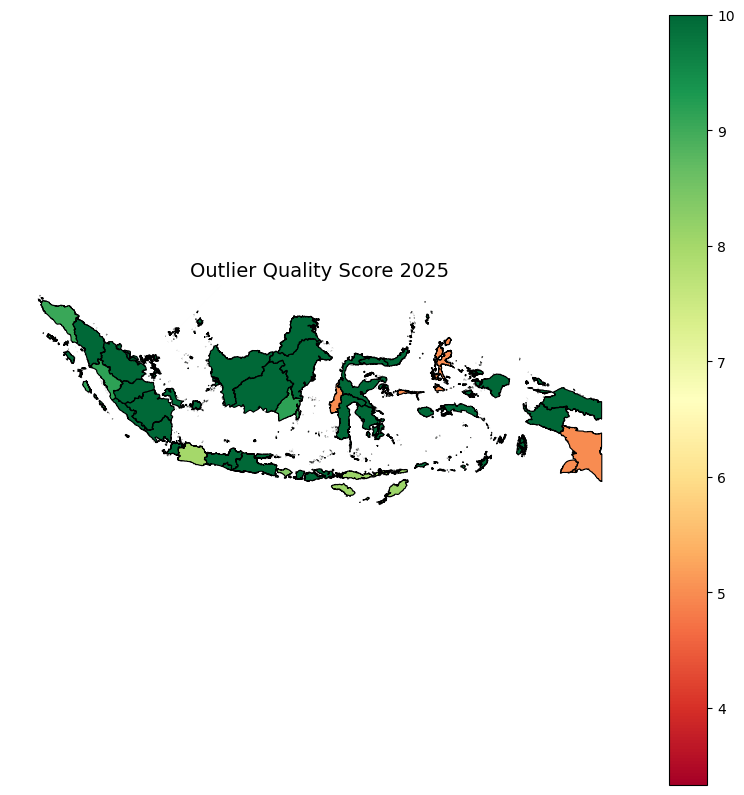

In [114]:
map_2025 = prov_weighted[prov_weighted["Tahun"] == 2025].copy()

gdf_merged = gdf.merge(
    map_2025,
    on="Provinsi",
    how="left"
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_merged.plot(
    column="Outlier_Score_0_10",
    cmap="RdYlGn",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Outlier Quality Score 2025", fontsize=14)
ax.axis("off")

plt.show()

In [115]:
gdf_merged[gdf_merged["Outlier_Score_0_10"].isna()]

,name_1,Shape_Leng,Shape_Area,geometry,Provinsi,Tahun,Anomaly_Rate_FullPanel,Outlier_Quality_Score,Total_Kab,Weighted_Anomaly,Weighted_Anomaly_Normalized,Outlier_Score_0_10
15,Papua Barat,61.138889,4.902578,"MULTIPOLYGON Z (((133.50651 -4.32324 -0.00002,...",Papua Barat,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,Papua Pegunungan,16.621657,4.172004,"POLYGON Z ((138.17845 -3.1108 -0.00002, 138.18...",Papua Pegunungan,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
prov_weighted.sort_values("Outlier_Score_0_10", ascending=True)

,Provinsi,Tahun,Anomaly_Rate_FullPanel,Outlier_Quality_Score,Total_Kab,Weighted_Anomaly,Weighted_Anomaly_Normalized,Outlier_Score_0_10
182,Sulawesi Utara,2022,0.666667,0.333333,15.0,2.581989,1.000000,3.333333
30,DKI Jakarta,2025,0.666667,0.333333,6.0,1.632993,0.632456,3.333333
147,Papua Selatan,2025,0.500000,0.500000,4.0,1.000000,0.387298,5.000000
161,Sulawesi Barat,2025,0.500000,0.500000,6.0,1.224745,0.474342,5.000000
120,Maluku Utara,2025,0.500000,0.500000,10.0,1.581139,0.612372,5.000000
...,...,...,...,...,...,...,...,...
81,Kalimantan Tengah,2021,0.000000,1.000000,14.0,0.000000,0.000000,10.000000
82,Kalimantan Tengah,2022,0.000000,1.000000,14.0,0.000000,0.000000,10.000000
83,Kalimantan Tengah,2023,0.000000,1.000000,14.0,0.000000,0.000000,10.000000
74,Kalimantan Selatan,2021,0.000000,1.000000,13.0,0.000000,0.000000,10.000000


In [122]:
import pandas as pd

# --- FILTER VALID REPORTS (at least 1 variable reported) ---
df_valid = df[df["jml_timbulan_tahun"].notna()].copy()

# --- COUNT REPORTING KAB/KOTA PER PROVINCE-YEAR ---
report_count = (
    df_valid.groupby(["Provinsi", "Tahun"])["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Kab_Report")
)

# --- TOTAL KAB/KOTA PER PROVINCE (REFERENCE BASELINE) ---
total_kab = (
    ref_df.groupby("Provinsi")["Kabupaten/Kota"]
    .nunique()
    .reset_index(name="Total_Kab")
)

# --- MERGE & CALCULATE REPORT RATE ---
report_rate = report_count.merge(
    total_kab,
    on="Provinsi",
    how="left"
)

report_rate["Report_Rate"] = (
    report_rate["Kab_Report"] /
    report_rate["Total_Kab"]
)

# --- OPTIONAL: CONVERT TO 0–10 SCALE ---
report_rate["Report_Rate_Score_0_10"] = report_rate["Report_Rate"] * 10

# --- SORT TO INSPECT ---
report_rate.sort_values(["Tahun", "Report_Rate"], ascending=[True, False]).head(20)

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate,Report_Rate_Score_0_10
35,Gorontalo,2019,1,6.0,0.166667,1.666667
47,Jawa Barat,2019,3,27.0,0.111111,1.111111
72,Kalimantan Selatan,2019,1,13.0,0.076923,0.769231
79,Kalimantan Tengah,2019,1,14.0,0.071429,0.714286
179,Sulawesi Utara,2019,1,15.0,0.066667,0.666667
174,Sulawesi Tenggara,2019,1,17.0,0.058824,0.588235
0,Aceh,2019,1,23.0,0.043478,0.434783
198,Sumatera Utara,2019,1,33.0,0.030303,0.303030
96,Kepulauan Bangka Belitung,2020,5,7.0,0.714286,7.142857
73,Kalimantan Selatan,2020,9,13.0,0.692308,6.923077


In [124]:
# --- MERGE REPORT RATE + OUTLIER SCORE ---
quality_df = report_rate.merge(
    prov_weighted[["Provinsi", "Tahun", "Outlier_Quality_Score"]],
    on=["Provinsi", "Tahun"],
    how="left"
)

# --- DEFINE WEIGHTS ---
w_report = 0.6
w_outlier = 0.4

# --- CALCULATE FINAL SCORE (0–1 scale) ---
quality_df["Final_Quality_Score"] = (
    w_report * quality_df["Report_Rate"] +
    w_outlier * quality_df["Outlier_Quality_Score"]
)

# --- CONVERT TO 0–10 SCALE ---
quality_df["Final_Quality_Score_0_10"] = (
    quality_df["Final_Quality_Score"] * 10
)

# --- CHECK RESULT ---
quality_df.head()

,Provinsi,Tahun,Kab_Report,Total_Kab,Report_Rate,Report_Rate_Score_0_10,Outlier_Quality_Score,Final_Quality_Score,Final_Quality_Score_0_10
0,Aceh,2019,1,23.0,0.043478,0.434783,1.0,0.426087,4.260870
1,Aceh,2020,6,23.0,0.260870,2.608696,1.0,0.556522,5.565217
2,Aceh,2021,2,23.0,0.086957,0.869565,1.0,0.452174,4.521739
3,Aceh,2022,8,23.0,0.347826,3.478261,1.0,0.608696,6.086957
4,Aceh,2023,13,23.0,0.565217,5.652174,1.0,0.739130,7.391304


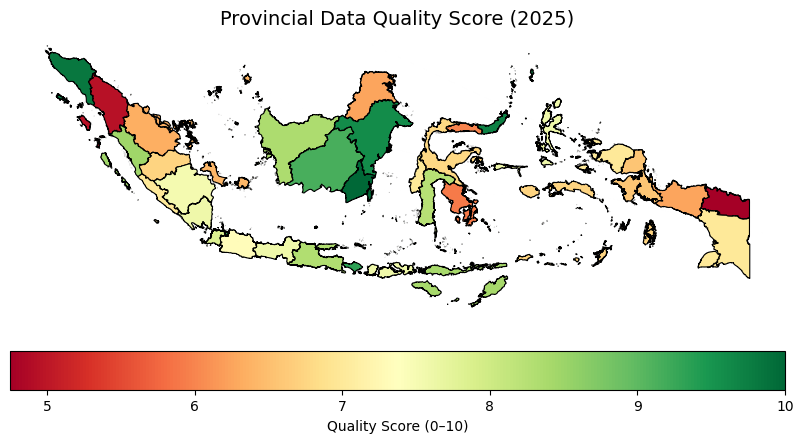

In [127]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_merged.plot(
    column="Final_Quality_Score_0_10",
    cmap="RdYlGn",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "pad": 0.05,
        "label": "Quality Score (0–10)"
    },
    ax=ax
)

ax.set_title("Provincial Data Quality Score (2025)", fontsize=14)
ax.axis("off")

plt.show()